
# Lab_4: FDM-capacitor

### Potential and Electric field from a capacitor

To find the potential generated by a capacitor  of two rectangular plates of width $d$ is challenging (see figure). In general, we can do some approximation based in infinite plates to get an intuition of the solution. In this approximation we have:

\begin{equation}
|\vec{E}| \approx \dfrac{\sigma}{2\epsilon_0}, \text{inside}\,,
\end{equation}
\begin{equation}
|\vec{E}| \approx 0, \text{  outside}\,.
\end{equation}

However, we know that the potential $\phi$ and the electric field $\vec{E}$ fulfill the Laplace's equation $\nabla^2\phi = 0$ in the region around the plates (where $\rho=0$).

* Use finite differences to solve the Laplace's equation in the neigborhood of this capacitor. Use the imshow or the contour function to plot the potential.

* Compute numerically (use finite difference method) the electric field.

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/Laplace_df_capacitor.png" width="500" height="300" />

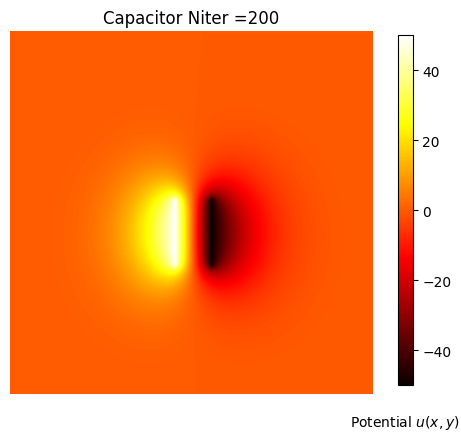

In [ ]:
# @title
# let's construc you own rutine. As an example:
from capacitor import capacitor_df #my rutine

# Plot imshow
Niter = 200
V = capacitor_df(Niter)
fig, ax = plt.subplots(figsize=(5,5) )
im = ax.imshow(V.copy(),cmap="hot",interpolation="bilinear",)
ax.set_axis_off()
ax.set_title('Capacitor Niter =%.1d'%Niter)

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.9, 0.15, 0.03, 0.7])
cbar_ax.set_xlabel("Potential $u(x,y)$", labelpad=20)
fig.colorbar(im, cax=cbar_ax)
plt.show()

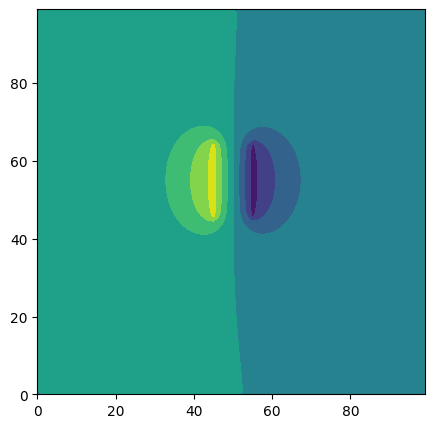

In [ ]:
# @title
plt.subplots(figsize=(5,5) )
plt.contourf(V)
plt.show()

# Solución

=== Jacobi sin Numba ===
Iteraciones: 2150
Error final: 9.985047e-04
Tiempo: 18.925095 s

=== Jacobi con Numba ===
Iteraciones: 2150
Error final: 9.985047e-04
Tiempo: 0.041658 s

=== Comparación ===
Max |V_py - V_nb| = 0.000000e+00
Tiempo cálculo campo eléctrico: 0.000333 s


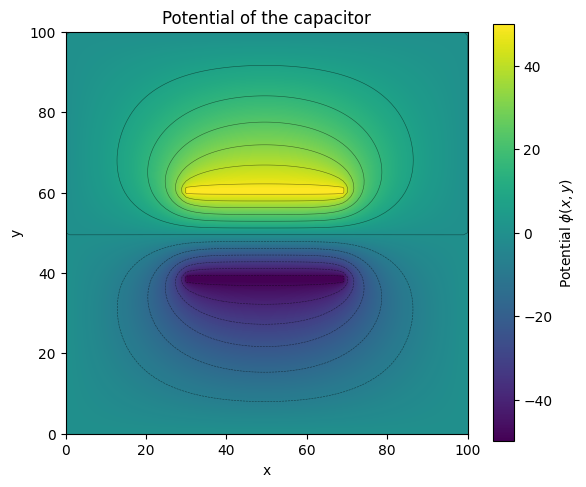

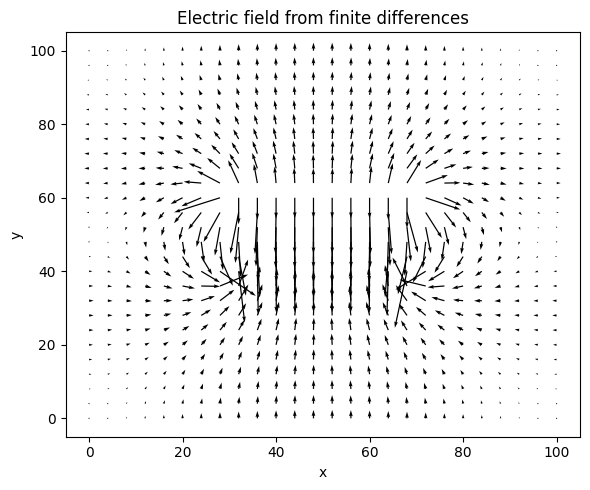

In [1]:
# @title
import time
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

# ------------------------------------------------------------
# Geometría del capacitor
# ------------------------------------------------------------
N = 101                 # malla 0..100, con Δ = 1
L = N - 1
V0 = 100.0              # diferencia de potencial total

plate_length = 40       # ancho de cada placa en x
gap = 20                # separación entre placas en y
thickness = 2           # grosor de cada placa en celdas
tol = 1e-3
max_iter = 20000

def build_capacitor_problem(N=101, plate_length=40, gap=20, thickness=2, V0=100.0):
    """
    Construye la condición inicial, la máscara de puntos fijos
    y los valores fijos del problema.
    """
    V_ini = np.zeros((N, N), dtype=np.float64)
    fixed = np.zeros((N, N), dtype=np.bool_)

    # Bordes externos a tierra
    fixed[0, :] = True
    fixed[-1, :] = True
    fixed[:, 0] = True
    fixed[:, -1] = True

    # Placas internas centradas
    y_mid = N // 2
    y_bottom = y_mid - gap // 2 - thickness
    y_top = y_mid + gap // 2

    x0 = (N - plate_length) // 2
    x1 = x0 + plate_length

    # Valores de las placas: una positiva y otra negativa
    V_ini[y_bottom:y_bottom + thickness, x0:x1] = -V0 / 2
    V_ini[y_top:y_top + thickness, x0:x1] = +V0 / 2

    fixed[y_bottom:y_bottom + thickness, x0:x1] = True
    fixed[y_top:y_top + thickness, x0:x1] = True

    return V_ini, fixed, (x0, x1, y_bottom, y_top)

# ------------------------------------------------------------
# Solución por Jacobi en Python puro
# ------------------------------------------------------------
def capacitor_df_py(V_ini, fixed, tol=1e-3, max_iter=20000):
    V_old = V_ini.copy()
    V_new = V_ini.copy()

    Ny, Nx = V_ini.shape
    diff = float("inf")
    iteration_count = 0

    while diff > tol and iteration_count < max_iter:
        V_old[:, :] = V_new

        for i in range(1, Ny - 1):
            for j in range(1, Nx - 1):
                if not fixed[i, j]:
                    V_new[i, j] = 0.25 * (
                        V_old[i + 1, j] + V_old[i - 1, j] +
                        V_old[i, j + 1] + V_old[i, j - 1]
                    )

        diff = np.max(np.abs(V_new - V_old))
        iteration_count += 1

    return V_new, iteration_count, diff

# ------------------------------------------------------------
# Solución por Jacobi con Numba
# ------------------------------------------------------------
@njit(cache=True)
def capacitor_df_numba(V_ini, fixed, tol, max_iter):
    V_old = V_ini.copy()
    V_new = V_ini.copy()

    Ny, Nx = V_ini.shape
    diff = 1e20
    iteration_count = 0

    while diff > tol and iteration_count < max_iter:
        V_old[:, :] = V_new

        for i in range(1, Ny - 1):
            for j in range(1, Nx - 1):
                if not fixed[i, j]:
                    V_new[i, j] = 0.25 * (
                        V_old[i + 1, j] + V_old[i - 1, j] +
                        V_old[i, j + 1] + V_old[i, j - 1]
                    )

        diff = 0.0
        for i in range(Ny):
            for j in range(Nx):
                d = abs(V_new[i, j] - V_old[i, j])
                if d > diff:
                    diff = d

        iteration_count += 1

    return V_new, iteration_count, diff

# ------------------------------------------------------------
# Campo eléctrico numérico por diferencias finitas
# ------------------------------------------------------------
def electric_field(V, dx=1.0, dy=1.0):
    Ex = np.zeros_like(V)
    Ey = np.zeros_like(V)

    # Derivada central en el interior
    Ex[:, 1:-1] = -(V[:, 2:] - V[:, :-2]) / (2 * dx)
    Ey[1:-1, :] = -(V[2:, :] - V[:-2, :]) / (2 * dy)

    # Derivadas unilaterales en los bordes
    Ex[:, 0] = -(V[:, 1] - V[:, 0]) / dx
    Ex[:, -1] = -(V[:, -1] - V[:, -2]) / dx
    Ey[0, :] = -(V[1, :] - V[0, :]) / dy
    Ey[-1, :] = -(V[-1, :] - V[-2, :]) / dy

    Emag = np.sqrt(Ex**2 + Ey**2)
    return Ex, Ey, Emag

# ------------------------------------------------------------
# Construir problema
# ------------------------------------------------------------
V_ini, fixed, geom = build_capacitor_problem(
    N=N,
    plate_length=plate_length,
    gap=gap,
    thickness=thickness,
    V0=V0
)
x0, x1, y_bottom, y_top = geom

# ------------------------------------------------------------
# Medición sin Numba
# ------------------------------------------------------------
inicio = time.perf_counter()
V_py, it_py, err_py = capacitor_df_py(V_ini, fixed, tol=tol, max_iter=max_iter)
fin = time.perf_counter()

print("=== Jacobi sin Numba ===")
print(f"Iteraciones: {it_py}")
print(f"Error final: {err_py:.6e}")
print(f"Tiempo: {fin - inicio:.6f} s\n")

# ------------------------------------------------------------
# Warm-up de Numba
# ------------------------------------------------------------
_ = capacitor_df_numba(V_ini, fixed, tol, max_iter)

# ------------------------------------------------------------
# Medición con Numba
# ------------------------------------------------------------
inicio = time.perf_counter()
V_nb, it_nb, err_nb = capacitor_df_numba(V_ini, fixed, tol, max_iter)
fin = time.perf_counter()

print("=== Jacobi con Numba ===")
print(f"Iteraciones: {it_nb}")
print(f"Error final: {err_nb:.6e}")
print(f"Tiempo: {fin - inicio:.6f} s\n")

print("=== Comparación ===")
print(f"Max |V_py - V_nb| = {np.max(np.abs(V_py - V_nb)):.6e}")

# ------------------------------------------------------------
# Campo eléctrico a partir de la solución numérica
# ------------------------------------------------------------
inicio = time.perf_counter()
Ex, Ey, Emag = electric_field(V_nb, dx=1.0, dy=1.0)
fin = time.perf_counter()

print(f"Tiempo cálculo campo eléctrico: {fin - inicio:.6f} s")

# ------------------------------------------------------------
# Gráfica del potencial
# ------------------------------------------------------------
plt.figure(figsize=(6, 5))
im = plt.imshow(
    V_nb,
    origin="lower",
    extent=[0, N - 1, 0, N - 1],
    interpolation="bilinear"
)
plt.colorbar(im, label="Potential $\\phi(x,y)$")
plt.contour(V_nb, levels=15, colors="k", linewidths=0.4, alpha=0.5)
plt.title("Potential of the capacitor")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Gráfica del campo eléctrico
# ------------------------------------------------------------
skip = 4
xs = np.arange(0, N, skip)
ys = np.arange(0, N, skip)
Xq, Yq = np.meshgrid(xs, ys)

plt.figure(figsize=(6, 5))
plt.quiver(
    Xq, Yq,
    Ex[::skip, ::skip], Ey[::skip, ::skip]
)
plt.title("Electric field from finite differences")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

## Potential and Electric Field from a Capacitor

Se resolvió la ecuación de Laplace $\nabla^2 \phi = 0$ en una región que contiene un capacitor formado por dos placas rectangulares, utilizando el método de diferencias finitas.

Las placas se modelaron como regiones internas con potencial fijo:

- Placa superior: $+\frac{V_0}{2}$
- Placa inferior: $-\frac{V_0}{2}$

y los bordes externos del dominio se fijaron en $\phi = 0$.

---

### Solución numérica del potencial

Se utilizó el método de Jacobi, donde cada punto del dominio se actualiza como el promedio de sus vecinos:

$$
\phi_{i,j}^{(k+1)}=\frac{1}{4}\left(\phi_{i+1,j}^{(k)}+\phi_{i-1,j}^{(k)}+\phi_{i,j+1}^{(k)}+\phi_{i,j-1}^{(k)}\right)
$$

El proceso se repitió hasta que el cambio máximo entre iteraciones consecutivas fuera menor que la tolerancia $10^{-3}$.

#### Resultados

- Iteraciones: **2150**
- Error final: $\sim 10^{-3}$

---

### Visualización del potencial

Se utilizó `imshow` junto con curvas de nivel (`contour`) para representar la distribución del potencial.

La gráfica muestra claramente:

- Regiones de potencial constante en las placas
- Variación suave del potencial entre ellas
- Líneas equipotenciales curvas cerca de los bordes, indicando efectos de borde

---

### Campo eléctrico

El campo eléctrico se calculó numéricamente a partir del potencial usando:

$$
\vec{E} = -\nabla \phi
$$

Es decir, mediante diferencias finitas:

$$
E_x \approx -\frac{\phi(x+\Delta x)-\phi(x-\Delta x)}{2\Delta x}, \quad
E_y \approx -\frac{\phi(y+\Delta y)-\phi(y-\Delta y)}{2\Delta y}
$$

El campo obtenido muestra:

- Líneas aproximadamente uniformes entre las placas (como predice la aproximación de placas infinitas)
- Desviaciones cerca de los bordes (efectos de borde)

Tiempo de cálculo del campo: **0.00033 s**

---

### Comparación de rendimiento (Python vs Numba)

Se comparó el tiempo de ejecución del método de Jacobi en Python puro y usando Numba:

| Método            | Tiempo (s) |
|------------------|------------|
| Jacobi (Python)  | 18.93      |
| Jacobi (Numba)   | 0.042      |

Ambos métodos produjeron exactamente la misma solución:

$$
\max |\phi_{\text{Python}} - \phi_{\text{Numba}}| = 0
$$

---

### Discusión

- El método de Jacobi permite resolver la ecuación de Laplace en geometrías donde no existe una solución analítica sencilla.
- El costo computacional está dominado por los ciclos iterativos sobre la malla.
- Numba reduce el tiempo de ejecución en más de dos órdenes de magnitud, acelerando significativamente el método sin afectar la precisión.
- El cálculo del campo eléctrico es mucho más rápido porque solo requiere derivadas numéricas una vez que el potencial ya está calculado.

---

### Conclusión

- El método de diferencias finitas permite obtener tanto el potencial como el campo eléctrico en un capacitor de geometría finita.
- La solución reproduce el comportamiento esperado: campo casi uniforme entre placas y efectos de borde en los extremos.
- Numba resulta muy útil para optimizar el tiempo de cómputo en métodos iterativos como Jacobi.
- Una vez obtenido el potencial, el campo eléctrico se calcula de forma rápida y directa.